<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/34_Unsupervised_Learning_in_Python/04_Discovering_Interpretable_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt
# Import confusion matrix and train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, LinearRegression

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/32_Supervised_Learning_with_scikit-learn/dataset/music_raw.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
music_df = pd.read_csv(url)
display(music_df.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/customer_satisfaction.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
customer_satisfaction = pd.read_csv(url)
display(customer_satisfaction.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/food_preservation.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
food_preservation = pd.read_csv(url)
display(food_preservation.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/30_Experimental_Design_in_Python/dataset/toy_durability.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
toy_durability = pd.read_csv(url)
display(toy_durability.head())

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,genre
0,64.0,0.69400,0.610,217400.0,0.590,0.000002,0.1500,-7.325,0.0362,137.838000,0.352,NaN
1,31.0,0.73900,0.565,260467.0,0.393,0.000845,0.1430,-9.309,0.0244,75.537000,0.229,Anime
2,57.0,0.00879,0.433,262867.0,0.815,0.000000,0.1380,-3.658,NaN,125.358000,0.461,Rock
3,63.0,0.01050,0.359,563893.0,0.762,0.281000,0.3680,-8.323,0.0320,89.259000,0.167,Rock
4,,0.30100,0.511,NaN,0.699,NaN,0.0884,NaN,0.0370,120.406497,0.496,Anime


,Unnamed: 0,ApplicationID,ResponseTime,InterestRate,CustomerInteraction,SatisfactionQuality
0,0,1,Fast,Low,Poor,0.204979
1,1,2,Moderate,High,Good,0.462610
2,2,3,Slow,Medium,Average,0.874398
3,3,4,Moderate,High,Average,0.428884
4,4,5,Fast,High,Poor,0.126637


,ProductID,PreservationMethod,FoodType,NutrientRetention,ShelfLife
0,1,Drying,Fruit,59.17,184.04
1,2,Freezing,Meat,72.29,104.46
2,3,Drying,Fruit,80.06,75.03
3,4,Canning,Fruit,98.50,103.34
4,5,Canning,Vegetable,59.09,97.46


,Toy_Type,Durability_Score
0,Recreational,67.2
1,Recreational,80.9
2,Recreational,69.7
3,Recreational,82.7
4,Educational,79.6


**Creating dummy variables**   
Being able to include categorical features in the model building process can enhance performance as they may add information that contributes to prediction accuracy.

The music_df dataset has been preloaded for you, and its shape is printed. Also, pandas has been imported as pd.

Now you will create a new DataFrame containing the original columns of music_df plus dummy variables from the "genre" column.

In [ ]:
# Create music_dummies
music_dummies = pd.get_dummies(music_df, drop_first=True)

# Print the new DataFrame's shape
print("Shape of music_dummies: {}".format(music_dummies.shape))

# As there were ten values in the "genre" column, nine new columns were added by a call of pd.get_dummies() using drop_first=True.
# After dropping the original "genre" column, there are still eight new columns in the DataFrame!

Shape of music_dummies: (1000, 13)


**Regression with categorical features**  
Now you have created music_dummies, containing binary features for each song's genre, it's time to build a ridge regression model to predict song popularity.

music_dummies has been preloaded for you, along with Ridge, cross_val_score, numpy as np, and a KFold object stored as kf.

The model will be evaluated by calculating the average RMSE, but first, you will need to convert the scores for each fold to positive values and take their square root. This metric shows the average error of our model's predictions, so it can be compared against the standard deviation of the target value—"popularity".

In [ ]:
# Create X and y
X = music_dummies.drop("popularity", axis=1).values
y = music_dummies["popularity"].values

# Instantiate a ridge model
ridge = Ridge(alpha=0.2)    #dont Forget to set alpha

# Define kf
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
scores = cross_val_score(ridge, X, y, cv=kf, scoring="neg_mean_squared_error")    #check Spell Specialy squared

# Calculate RMSE
rmse = np.sqrt(-scores)     #make - to + first
print("Average RMSE: {}".format(np.mean(rmse)))
print("Standard Deviation of the target array: {}".format(np.std(y)))

# An average RMSE of approximately 8.24 is lower than the standard deviation of the target variable (song popularity),
# suggesting the model is reasonably accurate.

Average RMSE: 10.033098690539362
Standard Deviation of the target array: 14.02156909907019


**Dropping missing data**  
Over the next three exercises, you are going to tidy the music_df dataset. You will create a pipeline to impute missing values and build a KNN classifier model, then use it to predict whether a song is of the "Rock" genre.

In this exercise specifically, you will drop missing values accounting for less than 5% of the dataset, and convert the "genre" column into a binary feature.

In [ ]:
# Print missing values for each column
print(music_df.isna().sum().sort_values())

# Remove values where less than 5% are missing  which is for now 50
music_df = music_df.dropna(subset=["genre", "popularity", "loudness", "liveness", "tempo"])

# Convert genre to a binary feature
music_df["genre"] = np.where(music_df["genre"] == "Rock", 1, 0)

print(music_df.isna().sum().sort_values())
print("Shape of the `music_df`: {}".format(music_df.shape))

#  The dataset has gone from 1000 observations down to 892,
#  but it is now in the correct format for binary classification and the remaining missing values can be imputed as part of a pipeline.

popularity            0
genre                 8
loudness             44
liveness             46
tempo                46
speechiness          59
instrumentalness     91
duration_ms          91
danceability        143
valence             143
energy              200
acousticness        200
dtype: int64
popularity            0
loudness              0
liveness              0
tempo                 0
genre                 0
duration_ms          43
instrumentalness     43
speechiness          54
danceability        129
valence             129
energy              181
acousticness        181
dtype: int64
Shape of the `music_df`: (906, 12)


/tmp/ipython-input-17-1713134585.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  music_df["genre"] = np.where(music_df["genre"] == "Rock", 1, 0)


**Pipeline for song genre prediction: I**  
Now it's time to build a pipeline. It will contain steps to impute missing values using the mean for each feature and build a KNN model for the classification of song genre.

The modified music_df dataset that you created in the previous exercise has been preloaded for you, along with KNeighborsClassifier and train_test_split.

In [ ]:
# Import modules
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Create X and y for the classification task
X = music_df.drop(["genre", "popularity"], axis=1).values
y = music_df["genre"].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate an imputer
imputer = SimpleImputer()

# Instantiate a knn model
knn = KNeighborsClassifier(n_neighbors = 3)

# Build steps for the pipeline
steps = [("imputer", imputer),
         ("knn", knn)]

**Pipeline for song genre prediction: II**  
Having set up the steps of the pipeline in the previous exercise, you will now use it on the music_df dataset to classify the genre of songs. What makes pipelines so incredibly useful is the simple interface that they provide.

X_train, X_test, y_train, and y_test have been preloaded for you, and confusion_matrix has been imported from sklearn.metrics.



In [ ]:
steps = [("imputer", imputer),
        ("knn", knn)]

# Create the pipeline
pipeline = Pipeline(steps)

# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Print the confusion matrix
print(confusion_matrix(y_test, y_pred))

# See how easy it is to scale our model building workflow using pipelines.
# In this case, the confusion matrix highlights that the model had 79 true positives and 82 true negatives!

[[47 44]
 [36 55]]


**Centering and scaling for regression**  
Now you have seen the benefits of scaling your data, you will use a pipeline to preprocess the music_df features and build a lasso regression model to predict a song's loudness.

X_train, X_test, y_train, and y_test have been created from the music_df dataset, where the target is "loudness" and the features are all other columns in the dataset. Lasso and Pipeline have also been imported for you.

Note that "genre" has been converted to a binary feature where 1 indicates a rock song, and 0 represents other genres.

In [ ]:
# Import StandardScaler and SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

# Create X and y for the regression task


# Split the data into training and testing s

# Create pipeline steps
steps = [("imputer", imputer),
         ("scaler", StandardScaler()),
         ("lasso", Lasso(alpha=0.5))]

# Instantiate the pipeline
pipeline = Pipeline(steps)

# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

# Calculate and print R-squared
print(pipeline.score(X_test, y_test))

# The model may have only produced an R-squared of 0.619,
#  but without scaling this exact model would have only produced a score of 0.35, which proves just how powerful scaling can be!



0.0


**Centering and scaling for classification**  
Now you will bring together scaling and model building into a pipeline for cross-validation.

Your task is to build a pipeline to scale features in the music_df dataset and perform grid search cross-validation using a logistic regression model with different values for the hyperparameter C. The target variable here is "genre", which contains binary values for rock as 1 and any other genre as 0.

StandardScaler, LogisticRegression, and GridSearchCV have all been imported for you.

In [ ]:
# Import necessary modules for preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/32_Supervised_Learning_with_scikit-learn/dataset/music_clean.csv"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
music_df = pd.read_csv(url)
display(music_df.head())

# Create X and y for the classification task
# Drop 'Unnamed: 0' and 'popularity' as they are not features for genre prediction
X = music_df.drop(["genre", "popularity"], axis=1)
y = music_df["genre"].values

# Select numeric columns for imputation and scaling
numeric_features = X.select_dtypes(include=np.number).columns

# Create a column transformer to apply SimpleImputer and StandardScaler to numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features)
    ],
    remainder='passthrough' # Keep non-numeric columns (if any) - though none are expected here
)

# Build the steps for the pipeline including the preprocessor and the model
steps = [("preprocessor", preprocessor),
         ("logreg", LogisticRegression())]
pipeline = Pipeline(steps)

# Create the parameter space for the grid search
parameters = {"logreg__C": np.linspace(0.001, 1.0, 20)}

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=21)

# Instantiate the grid search object
cv = GridSearchCV(pipeline, param_grid=parameters)

# Fit to the training data
cv.fit(X_train, y_train)

# Print the best score and best parameters found by the grid search
print(cv.best_score_, "\n", cv.best_params_)

,Unnamed: 0,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,genre
0,36506,60.0,0.896000,0.726,214547.0,0.177,0.000002,0.1160,-14.824,0.0353,92.934,0.618,1
1,37591,63.0,0.003840,0.635,190448.0,0.908,0.083400,0.2390,-4.795,0.0563,110.012,0.637,1
2,37658,59.0,0.000075,0.352,456320.0,0.956,0.020300,0.1250,-3.634,0.1490,122.897,0.228,1
3,36060,54.0,0.945000,0.488,352280.0,0.326,0.015700,0.1190,-12.020,0.0328,106.063,0.323,1
4,35710,55.0,0.245000,0.667,273693.0,0.647,0.000297,0.0633,-7.787,0.0487,143.995,0.300,1


0.9 
 {'logreg__C': np.float64(1.0)}


### Evaluating Multiple model

**Visualizing regression model performance**  
Now you have seen how to evaluate multiple models out of the box, you will build three regression models to predict a song's "energy" levels.

The music_df dataset has had dummy variables for "genre" added. Also, feature and target arrays have been created, and these have been split into X_train, X_test, y_train, and y_test.

The following have been imported for you: LinearRegression, Ridge, Lasso, cross_val_score, and KFold.

/tmp/ipython-input-74-2374570811.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=models.keys())


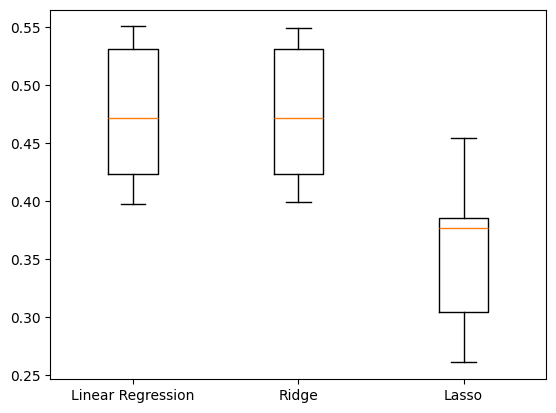

In [ ]:
models = {"Linear Regression": LinearRegression(), "Ridge": Ridge(alpha=0.1), "Lasso": Lasso(alpha=0.1)}
results = []

# Loop through the models' values
for model in models.values():
  kf = KFold(n_splits=6, random_state=42, shuffle=True)

  # Perform cross-validation
  cv_scores = cross_val_score(model, X_train, y_train, cv=kf)

  # Append the results
  results.append(cv_scores)

# Create a box plot of the results
plt.boxplot(results, labels=models.keys())
plt.show()

# Lasso regression is not a good model for this problem,
# while linear regression and ridge perform fairly equally. Let's make predictions on the test set, and see if the RMSE can guide us on model selection.

**Predicting on the test set**  
In the last exercise, linear regression and ridge appeared to produce similar results. It would be appropriate to select either of those models; however, you can check predictive performance on the test set to see if either one can outperform the other.

You will use root mean squared error (RMSE) as the metric. The dictionary models, containing the names and instances of the two models, has been preloaded for you along with the training and target arrays X_train_scaled, X_test_scaled, y_train, and y_test.

In [ ]:
# Import root_mean_squared_error
from sklearn.metrics import root_mean_squared_error

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for name, model in models.items():
  # Fit the model to the training data
  model =   model.fit(X_train_scaled, y_train)

  # Make predictions on the test set
  y_pred = model.predict(X_test_scaled)

  # Calculate the test_rmse
  test_rmse = root_mean_squared_error(y_test, y_pred)
  print("{} Test Set RMSE: {}".format(name, test_rmse))

  # The linear regression model just edges the best performance, although the difference
  # is a RMSE of 0.00001 for popularity! Now let's look at classification model selection.

Linear Regression Test Set RMSE: 0.38436128962021787
Ridge Test Set RMSE: 0.3843622345809156
Lasso Test Set RMSE: 0.4209624890259513


**Visualizing classification model performance**  
In this exercise, you will be solving a classification problem where the "popularity" column in the music_df dataset has been converted to binary values, with 1 representing popularity more than or equal to the median for the "popularity" column, and 0 indicating popularity below the median.

Your task is to build and visualize the results of three different models to classify whether a song is popular or not.

The data has been split, scaled, and preloaded for you as X_train_scaled, X_test_scaled, y_train, and y_test. Additionally, KNeighborsClassifier, DecisionTreeClassifier, and LogisticRegression have been imported.

In [ ]:
# Create models dictionary
models = {"Logistic Regression": LogisticRegression(), "KNN": KNeighborsClassifier(), "Decision Tree Classifier": DecisionTreeClassifier()}
results = []

# Loop through the models' values
for model in models.values():

  # Instantiate a KFold object
  kf = KFold(n_splits=6, random_state=12, shuffle=True)

  # Perform cross-validation
  cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kf)
  results.append(cv_results)
plt.boxplot(results, labels=models.keys())
plt.show()

# Looks like logistic regression is the best candidate based on the cross-validation results! Let's wrap up by building a pipeline

**Pipeline for predicting song popularity**  
For the final exercise, you will build a pipeline to impute missing values, scale features, and perform hyperparameter tuning of a logistic regression model. The aim is to find the best parameters and accuracy when predicting song genre!

All the models and objects required to build the pipeline have been preloaded for you.



In [ ]:
# Create steps
steps = [("imp_mean", SimpleImputer()),
         ("scaler", StandardScaler()),
         ("logreg", LogisticRegression())]

# Set up pipeline
pipeline = Pipeline(steps)
params = {"logreg__solver": ["newton-cg", "saga", "lbfgs"],
         "logreg__C": np.linspace(0.001, 1.0, 10)}

# Create the GridSearchCV object
tuning = GridSearchCV(pipeline, param_grid=params)
tuning.fit(X_train, y_train)
y_pred = tuning.predict(X_test)

# Compute and print performance
print("Tuned Logistic Regression Parameters: {}, Accuracy: {}".format(tuning.best_params_, tuning.score(X_test, y_test)))

# you've selected a model, built a preprocessing pipeline, and performed hyperparameter tuning to create a model that is 82% accurate in predicting song genres!

Tuned Logistic Regression Parameters: {'logreg__C': np.float64(1.0), 'logreg__solver': 'newton-cg'}, Accuracy: 0.85
